<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/4_Feature_Scaling_Standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [96]:
 df = df.iloc[:,2:5]
 df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


# Train test split

In [97]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)

x_train.shape, x_test.shape

((280, 2), (120, 2))

train_test_split()

Purpose:

Split dataset into training and testing data.

Syntax:

train_test_split(X, y, test_size=0.3, random_state=0)

Parameters:

X → Features/Input columns

y → Target/Output column

test_size → Percentage of test data

random_state → Fixes random split


Returns:

X_train

X_test

y_train

y_test

Visual:

Data

 │
 ├── 70% → Training Data

 │      ├── X_train

 │      └── y_train

 │

 └── 30% → Testing Data

        ├── X_test

        └── y_test


shape:

(rows, columns)

Example:

(280, 2)

280 rows and 2 columns

# StandardScaler

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(x_train) # mean and std

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [99]:
x_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


# StandardScaler

### Purpose

StandardScaler is used to scale features so that all columns have a similar range. This helps many Machine Learning algorithms perform better.

---

### Import StandardScaler

```python
from sklearn.preprocessing import StandardScaler
```

Imports the StandardScaler class from Scikit-Learn.

---

### Create Scaler Object

```python
scaler = StandardScaler()
```

Creates a scaling object.

**Memory:** `Scaler = Scaling Machine`

---

### Learn Scaling Parameters

```python
scaler.fit(x_train)
```

Learns the following from the training data:

* Mean (μ)
* Standard Deviation (σ)

**Memory:** `fit() = Learn`

> Always fit on training data only.

---

### Scale Training Data

```python
x_train_scaled = scaler.transform(x_train)
```

Applies the learned Mean and Standard Deviation to scale the training data.

**Memory:** `transform() = Convert Data`

---

### Scale Testing Data

```python
x_test_scaled = scaler.transform(x_test)
```

Applies the same scaling parameters learned from the training data to the test data.

**Rule:** Never use `fit()` on test data.

---

## Workflow

```text
x_train
   │
   ▼
fit()
   │
   ├── Mean
   └── Std
   │
   ▼
transform()
   │
   ▼
x_train_scaled

x_test
   │
   ▼
transform()
   │
   ▼
x_test_scaled
```

---

## Memory Trick

```text
fit()          → Learn
transform()    → Convert
fit_transform() → Learn + Convert
predict()      → Predict
```

---

## One-Line Summary

StandardScaler learns the Mean and Standard Deviation from the training data and uses them to convert both training and testing data into a standardized scale.


In [100]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [101]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
# columns=x_train.columns - index(['age', 'Salary'])
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [102]:
x_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [103]:
x_test_scaled

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804
...,...,...
115,1.091743,-0.139018
116,0.699584,1.769639
117,-0.672973,0.555039
118,0.797624,0.352606


In [104]:
x_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [105]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


# Effect of scaling

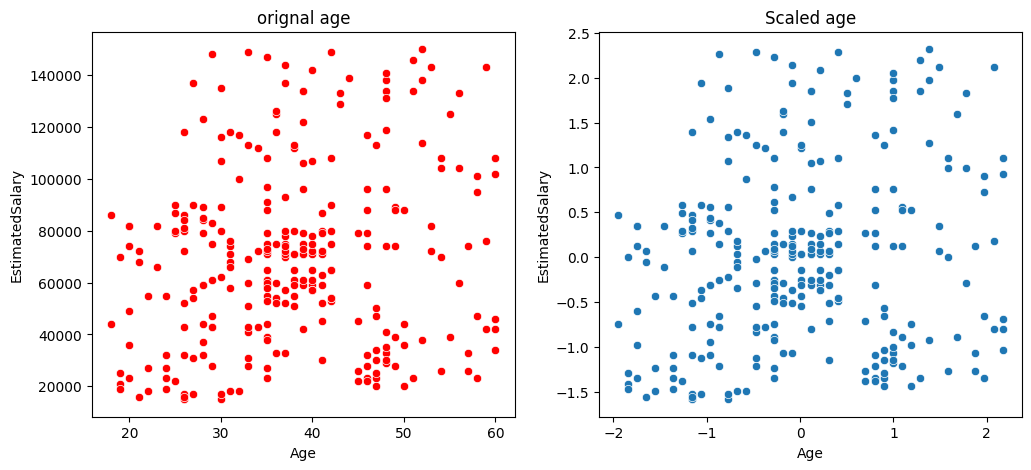

In [106]:
import matplotlib.pyplot as plt
fig,  ax =plt.subplots(1,2, figsize=(12,5))


sns.scatterplot(data=x_train, x='Age', y='EstimatedSalary', ax=ax[0], color='red')
ax[0].set_title('orignal age')
sns.scatterplot(data=x_train_scaled, x='Age', y='EstimatedSalary', ax=ax[1])
ax[1].set_title('Scaled age')
plt.show()

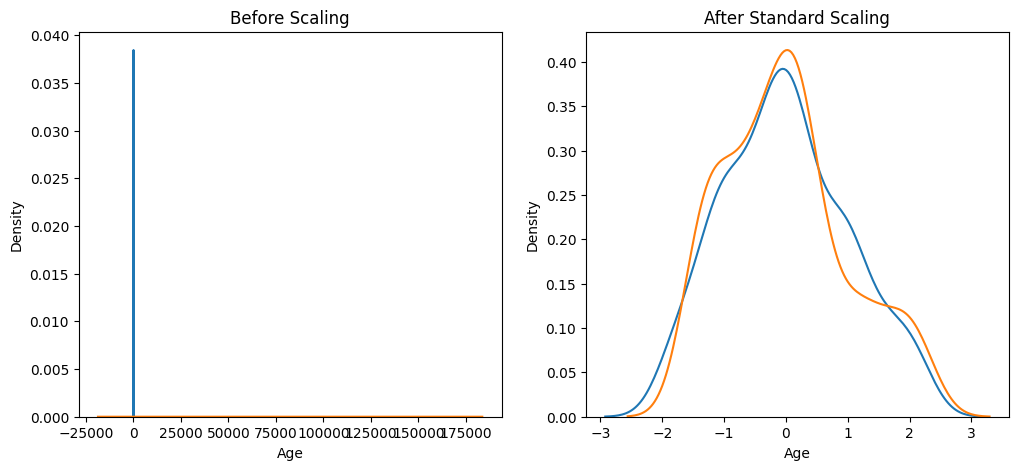

In [107]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

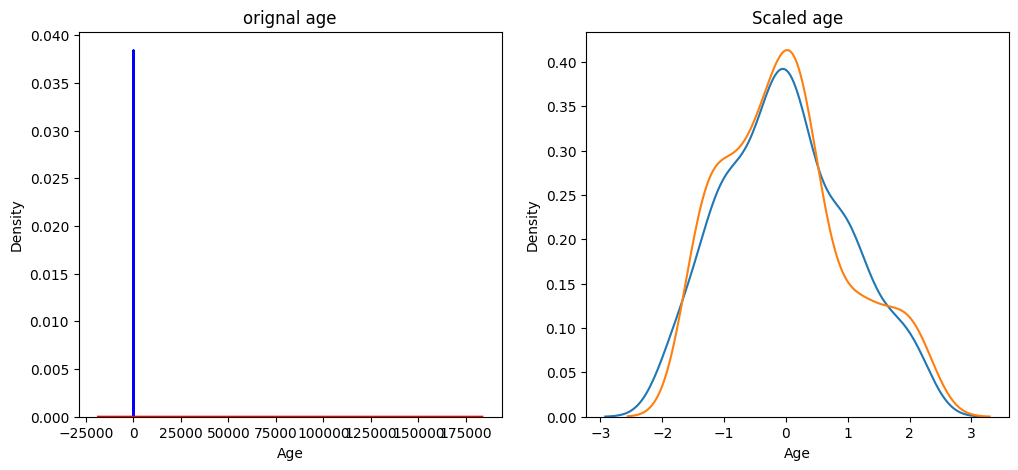

In [108]:
import matplotlib.pyplot as plt
fig,  ax =plt.subplots(1,2, figsize=(12,5))


sns.kdeplot(data=x_train, x='Age', ax=ax[0], color='blue')
sns.kdeplot(data=x_train,x='EstimatedSalary', ax=ax[0], color='red')
ax[0].set_title('orignal age')
sns.kdeplot(data=x_train_scaled, x='Age', ax=ax[1])
sns.kdeplot(data=x_train_scaled, x='EstimatedSalary', ax=ax[1])
ax[1].set_title('Scaled age')
plt.show()

# Comparison of Distribution

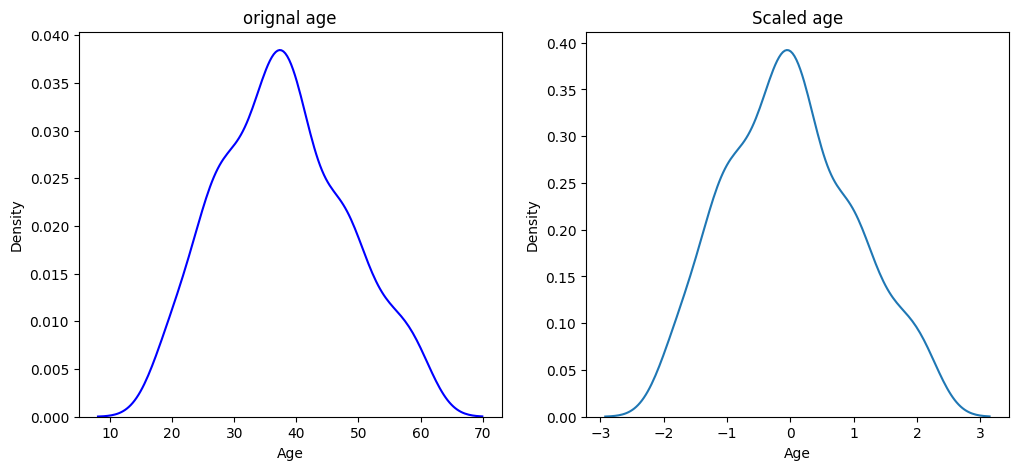

In [109]:
import matplotlib.pyplot as plt
fig,  ax =plt.subplots(1,2, figsize=(12,5))


sns.kdeplot(data=x_train, x='Age', ax=ax[0], color='blue')

ax[0].set_title('orignal age')
sns.kdeplot(data=x_train_scaled, x='Age', ax=ax[1])

ax[1].set_title('Scaled age')
plt.show()

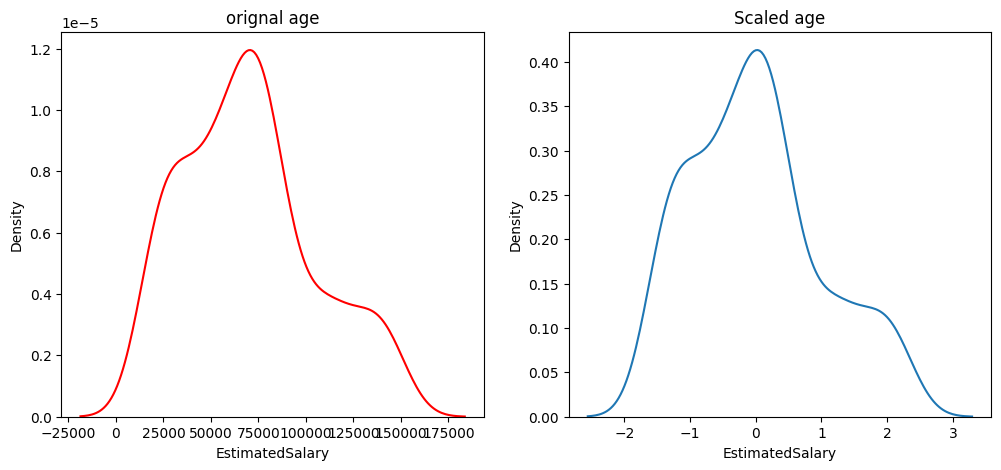

In [110]:
import matplotlib.pyplot as plt
fig,  ax =plt.subplots(1,2, figsize=(12,5))



sns.kdeplot(data=x_train,x='EstimatedSalary', ax=ax[0], color='red')
ax[0].set_title('orignal age')

sns.kdeplot(data=x_train_scaled, x='EstimatedSalary', ax=ax[1])
ax[1].set_title('Scaled age')
plt.show()

# Why scaling is important?

In [111]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()


In [112]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train, y_train)


LogisticRegression()

In [113]:
LogisticRegression()

LogisticRegression()

In [114]:
y_pred = lr.predict(x_test)
y_pred_scaler = lr_scaled.predict(x_test_scaled)


In [115]:
from sklearn.metrics import accuracy_score
print("Actually", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scaler))


Actually 0.875
Scaled 0.6583333333333333


In [120]:
from sklearn.tree import DecisionTreeClassifier

In [123]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [124]:
dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [125]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [126]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667
